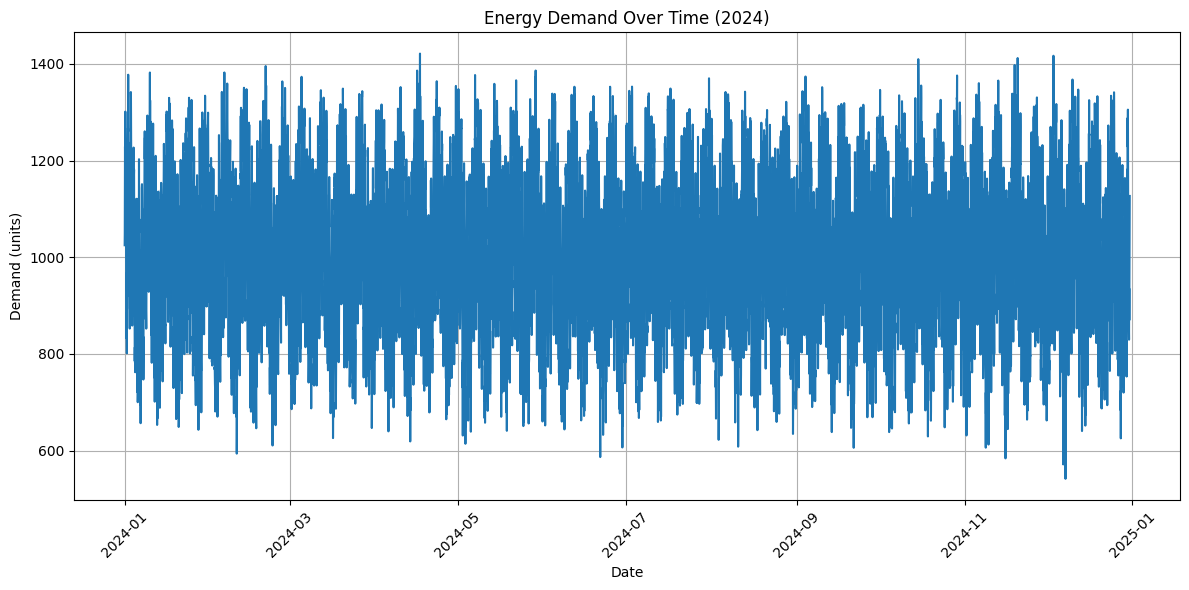

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Sample energy demand data
np.random.seed(42)
dates = pd.date_range(start='2024-01-01', end='2024-12-31', freq='h')  # Notice the regular hyphens
demand = 1000 + 200 * np.sin(np.arange(len(dates)) * 2 * np.pi / 24) + \
    100 * np.sin(np.arange(len(dates)) * 2 * np.pi / (24 * 7)) + \
    np.random.normal(0, 50, len(dates))
df = pd.DataFrame({'timestamp': dates, 'demand': demand})

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(df['timestamp'], df['demand'])
plt.title('Energy Demand Over Time (2024)')
plt.xlabel('Date')
plt.ylabel('Demand (units)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('energy_demand_plot.png')
plt.show()


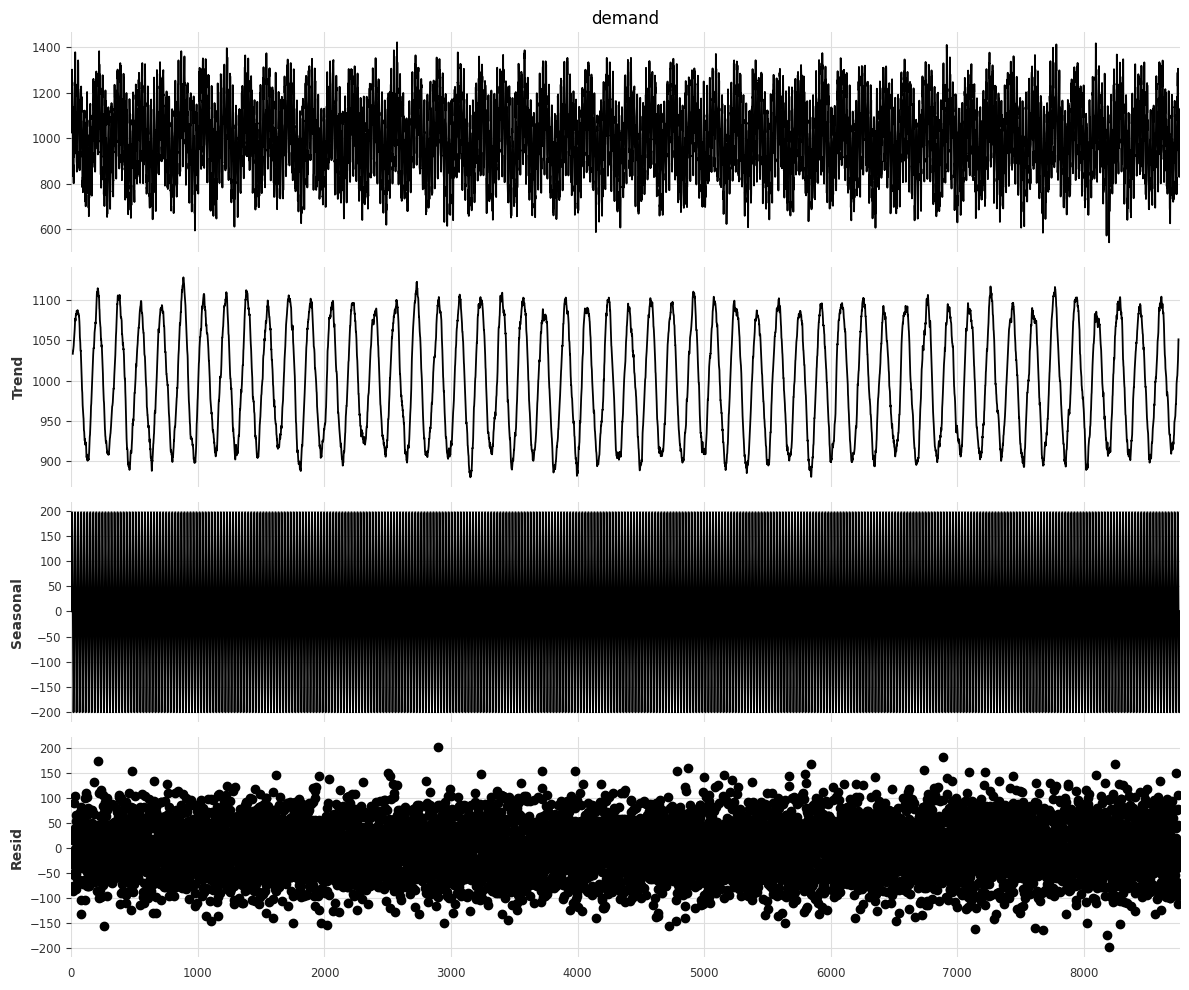


Augmented Dickey-Fuller Test Results:
ADF Statistic: -24.62369890119252
p-value: 0.0
Critical Values:
	1%: -3.431099882538333
	5%: -2.8618713981324873
	10%: -2.56694639826003


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# Generate data
np.random.seed(42)
dates = pd.date_range(start='2024-01-01', end='2024-12-31', freq='h')
demand = 1000 + 200 * np.sin(np.arange(len(dates)) * 2 * np.pi / 24) + \
    100 * np.sin(np.arange(len(dates)) * 2 * np.pi / (24 * 7)) + \
    np.random.normal(0, 50, len(dates))
df = pd.DataFrame({'timestamp': dates, 'demand': demand})

# Statistical analysis
decomposition = seasonal_decompose(df['demand'], period=24)
stationarity = adfuller(df['demand'])

# Create plot using statsmodels built-in plotting
fig = decomposition.plot()
fig.set_size_inches(12, 10)
plt.tight_layout()
plt.savefig('time_series_decomposition.png')
plt.show()

# Print stationarity test results
print('\nAugmented Dickey-Fuller Test Results:')
print(f'ADF Statistic: {stationarity[0]}')
print(f'p-value: {stationarity[1]}')
print('Critical Values:')
for key, value in stationarity[4].items():
    print(f'\t{key}: {value}')


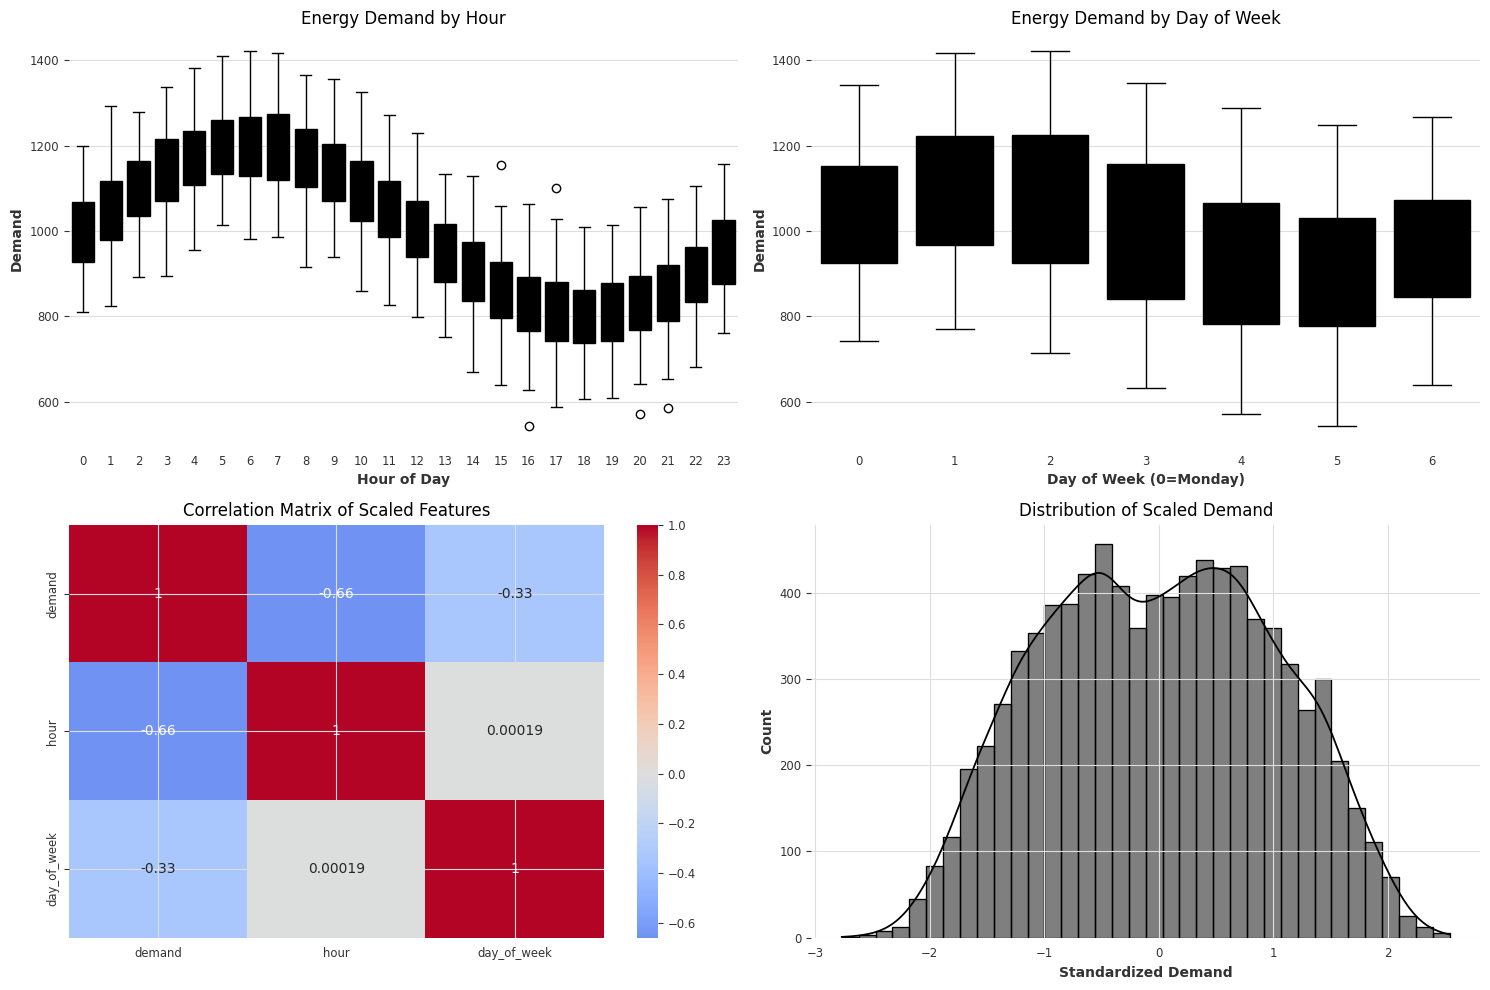


Scaled Features Statistics:
             demand          hour   day_of_week
count  8.761000e+03  8.761000e+03  8.761000e+03
mean  -4.703970e-16  9.205182e-17 -6.244925e-17
std    1.000057e+00  1.000057e+00  1.000057e+00
min   -2.767008e+00 -1.660968e+00 -1.493236e+00
25%   -7.892647e-01 -9.387258e-01 -9.940850e-01
50%    4.045994e-03 -7.203465e-02  4.216087e-03
75%    7.722623e-01  7.946565e-01  1.002517e+00
max    2.542475e+00  1.661348e+00  1.501668e+00


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit

# Generate data
np.random.seed(42)
dates = pd.date_range(start='2024-01-01', end='2024-12-31', freq='h')
demand = 1000 + 200 * np.sin(np.arange(len(dates)) * 2 * np.pi / 24) + \
    100 * np.sin(np.arange(len(dates)) * 2 * np.pi / (24 * 7)) + \
    np.random.normal(0, 50, len(dates))
df = pd.DataFrame({'timestamp': dates, 'demand': demand})

# Prepare features
def prepare_ml_features(df):
    df['hour'] = df['timestamp'].dt.hour
    df['day_of_week'] = df['timestamp'].dt.dayofweek

    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(df[['demand', 'hour', 'day_of_week']])

    return pd.DataFrame(scaled_features, columns=['demand', 'hour', 'day_of_week'])

scaled_df = prepare_ml_features(df)

# Create visualization
plt.figure(figsize=(15, 10))

# Plot 1: Box plot of demand by hour
plt.subplot(221)
sns.boxplot(x=df['hour'], y=df['demand'])
plt.title('Energy Demand by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Demand')

# Plot 2: Box plot of demand by day of week
plt.subplot(222)
sns.boxplot(x=df['day_of_week'], y=df['demand'])
plt.title('Energy Demand by Day of Week')
plt.xlabel('Day of Week (0=Monday)')
plt.ylabel('Demand')

# Plot 3: Heatmap of correlations
plt.subplot(223)
correlation_matrix = scaled_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Scaled Features')

# Plot 4: Distribution of scaled demand
plt.subplot(224)
sns.histplot(scaled_df['demand'], kde=True)
plt.title('Distribution of Scaled Demand')
plt.xlabel('Standardized Demand')
plt.ylabel('Count')

plt.tight_layout()
plt.savefig('feature_analysis.png')
plt.show()

# Print some statistical information
print("\nScaled Features Statistics:")
print(scaled_df.describe())


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpmemmca_z/rl_i2rcq.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpmemmca_z/8rbt015g.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=24661', 'data', 'file=/tmp/tmpmemmca_z/rl_i2rcq.json', 'init=/tmp/tmpmemmca_z/8rbt015g.json', 'output', 'file=/tmp/tmpmemmca_z/prophet_modelkdd2cw0p/prophet_model-20250120183212.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:32:12 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:32:14 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


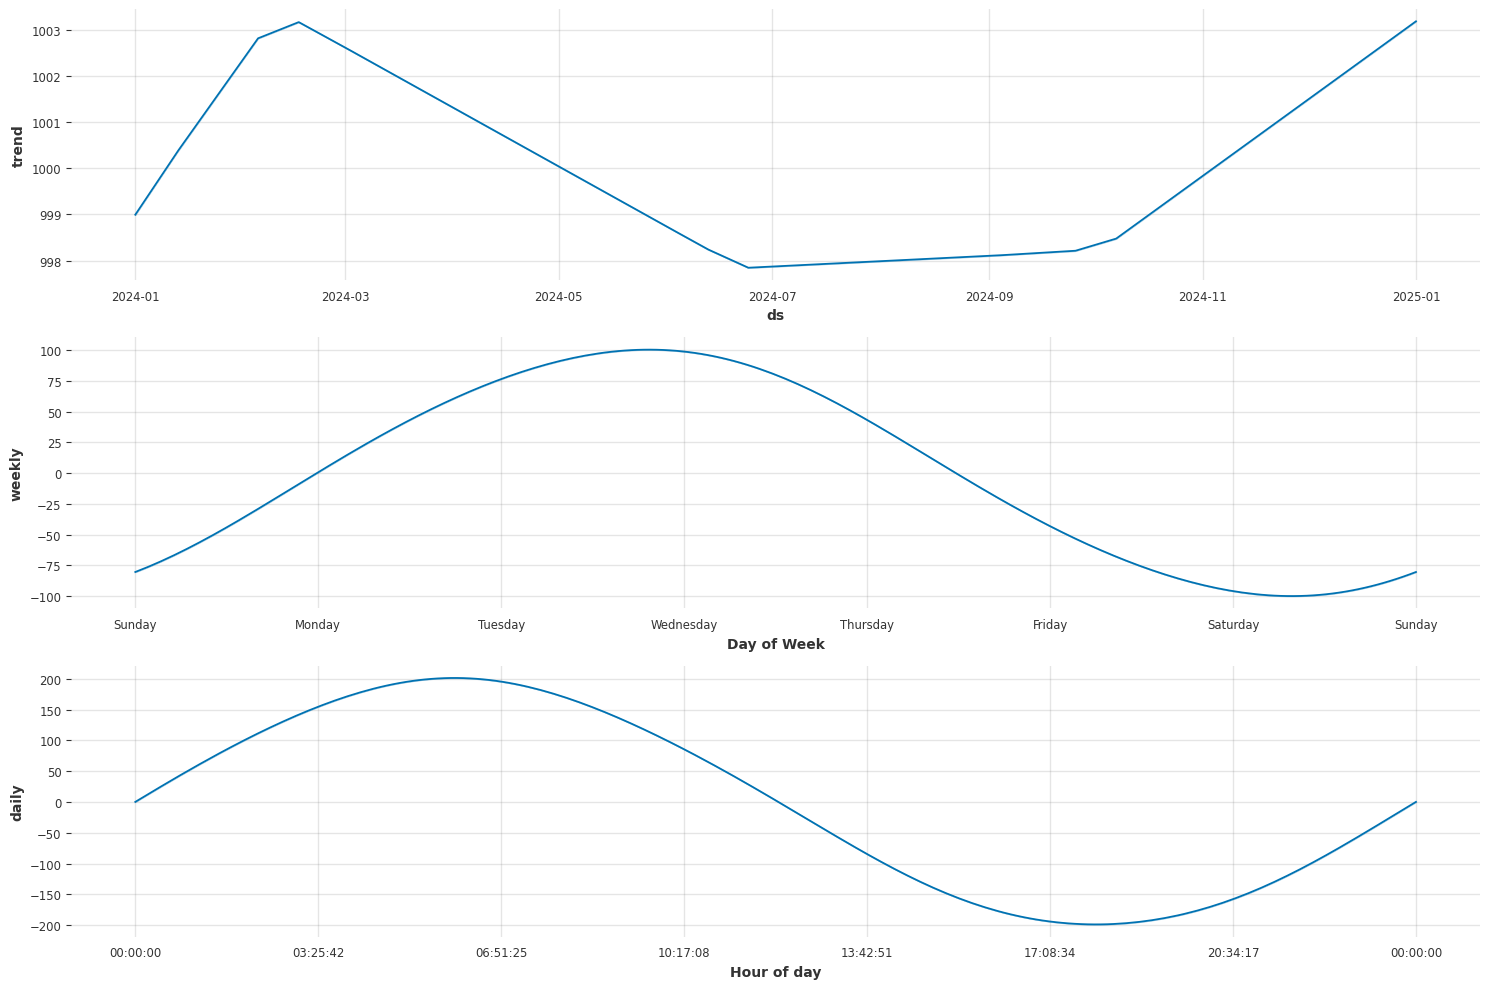


Forecast Statistics (Next 24 Hours):
                        ds         yhat   yhat_lower   yhat_upper
count                   24    24.000000    24.000000    24.000000
mean   2024-12-31 12:30:00  1097.160619  1031.011815  1160.702446
min    2024-12-31 01:00:00   904.508808   839.220896   970.324596
25%    2024-12-31 06:45:00   960.887868   893.612354  1023.524306
50%    2024-12-31 12:30:00  1102.299565  1036.292122  1167.694067
75%    2024-12-31 18:15:00  1227.958929  1160.456611  1289.565417
max    2025-01-01 00:00:00  1293.123186  1230.223885  1360.634941
std                    NaN   138.869689   139.664122   138.928041


In [16]:
import pandas as pd
import numpy as np
from prophet import Prophet
import matplotlib.pyplot as plt

# Generate data
np.random.seed(42)
dates = pd.date_range(start='2024-01-01', end='2024-12-31', freq='h')
demand = 1000 + 200 * np.sin(np.arange(len(dates)) * 2 * np.pi / 24) + \
    100 * np.sin(np.arange(len(dates)) * 2 * np.pi / (24 * 7)) + \
    np.random.normal(0, 50, len(dates))
df = pd.DataFrame({'timestamp': dates, 'demand': demand})

# Prophet forecast function
def prophet_forecast(df, periods=24):
    prophet_df = df.rename(columns={'timestamp': 'ds', 'demand': 'y'})
    model = Prophet(daily_seasonality=True, weekly_seasonality=True)
    model.fit(prophet_df)
    future = model.make_future_dataframe(periods=periods, freq='h')
    forecast = model.predict(future)
    return forecast, model

# Generate forecast
prophet_results, m = prophet_forecast(df)

# Plot components
fig = m.plot_components(prophet_results)
fig.set_size_inches(15, 10)
plt.tight_layout()
plt.savefig('prophet_components.png')
plt.show()

# Print forecast metrics for next 24 hours
print("\nForecast Statistics (Next 24 Hours):")
print(prophet_results[prophet_results['ds'] > df['timestamp'].max()]
      [['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
      .describe())


/usr/local/lib/python3.11/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


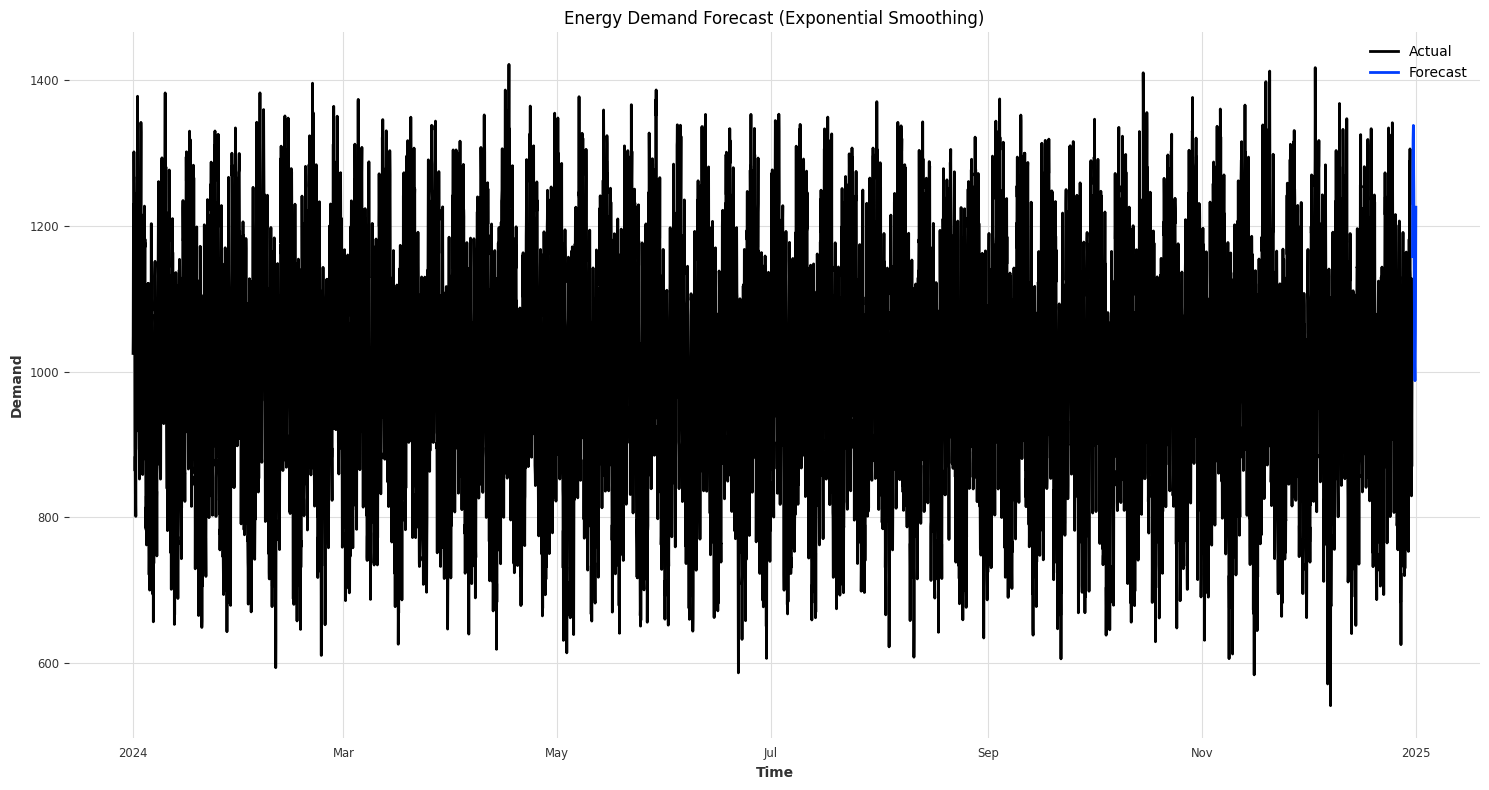


Forecast Statistics:
component       demand
count        24.000000
mean       1164.222799
std         118.899790
min         987.477768
25%        1048.813301
50%        1165.819377
75%        1264.807427
max        1337.456106


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from darts import TimeSeries
from darts.models import ExponentialSmoothing

# Generate data
np.random.seed(42)
dates = pd.date_range(start='2024-01-01', end='2024-12-31', freq='h')
demand = 1000 + 200 * np.sin(np.arange(len(dates)) * 2 * np.pi / 24) + \
    100 * np.sin(np.arange(len(dates)) * 2 * np.pi / (24 * 7)) + \
    np.random.normal(0, 50, len(dates))
df = pd.DataFrame({'timestamp': dates, 'demand': demand})

# Convert to Darts TimeSeries
series = TimeSeries.from_dataframe(df, 'timestamp', 'demand')

# Create and train model
model = ExponentialSmoothing()
model.fit(series)

# Generate forecast
forecast = model.predict(24)

# Plotting
plt.figure(figsize=(15, 8))

# Plot actual data
series.plot(label='Actual')

# Plot forecast
forecast.plot(label='Forecast')

plt.title('Energy Demand Forecast (Exponential Smoothing)')
plt.xlabel('Time')
plt.ylabel('Demand')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('forecast_comparison.png')
plt.show()

# Print forecast statistics
print("\nForecast Statistics:")
print(forecast.pd_dataframe().describe())


In [9]:
!pip install dask

<Figure size 2000x3000 with 0 Axes>

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpzx14_axb/87vg3fy_.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpzx14_axb/n7uj2k8o.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=53149', 'data', 'file=/tmp/tmpzx14_axb/87vg3fy_.json', 'init=/tmp/tmpzx14_axb/n7uj2k8o.json', 'output', 'file=/tmp/tmpzx14_axb/prophet_model2r8wl3qu/prophet_model-20250120184754.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:47:54 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:47:54 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
<ipython-input-9-4d13371462a0>:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be inc

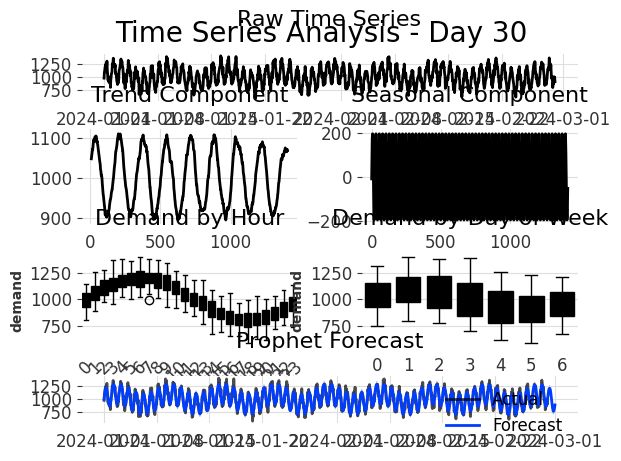

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from statsmodels.tsa.seasonal import seasonal_decompose
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from prophet import Prophet

# Create figure with subplots
fig = plt.figure(figsize=(20, 30))  # Increased figure size

# Create GridSpec with more space between plots
gs = plt.GridSpec(4, 2, height_ratios=[1, 2, 2, 1], hspace=0.4, wspace=0.3)

def generate_data(start_date, periods=24*30):
    dates = pd.date_range(start=start_date, periods=periods, freq='h')
    demand = 1000 + 200 * np.sin(np.arange(len(dates)) * 2 * np.pi / 24) + \
        100 * np.sin(np.arange(len(dates)) * 2 * np.pi / (24 * 7)) + \
        np.random.normal(0, 50, len(dates))
    return pd.DataFrame({'timestamp': dates, 'demand': demand})

def update(frame):
    plt.clf()  # Clear the entire figure

    # Generate new data with increasing timeframe
    start_date = pd.Timestamp('2024-01-01')
    current_date = start_date + pd.Timedelta(days=frame)
    df = generate_data(start_date, periods=(frame + 30) * 24)

    # Plot 1: Raw time series (spanning full width)
    ax1 = plt.subplot(gs[0, :])
    ax1.plot(df['timestamp'], df['demand'], linewidth=2)
    ax1.set_title('Raw Time Series', fontsize=16, pad=20)
    ax1.tick_params(axis='both', labelsize=12)

    # Plot 2: Decomposition components
    decomposition = seasonal_decompose(df['demand'], period=24)

    # Trend
    ax2_trend = plt.subplot(gs[1, 0])
    ax2_trend.plot(df.index, decomposition.trend, linewidth=2)
    ax2_trend.set_title('Trend Component', fontsize=16, pad=20)
    ax2_trend.tick_params(axis='both', labelsize=12)

    # Seasonal
    ax2_seasonal = plt.subplot(gs[1, 1])
    ax2_seasonal.plot(df.index, decomposition.seasonal, linewidth=2)
    ax2_seasonal.set_title('Seasonal Component', fontsize=16, pad=20)
    ax2_seasonal.tick_params(axis='both', labelsize=12)

    # Create 2x2 grid for sklearn plots
    ax3_1 = plt.subplot(gs[2, 0])
    ax3_2 = plt.subplot(gs[2, 1])

    # Feature analysis plots
    df['hour'] = df['timestamp'].dt.hour
    df['day_of_week'] = df['timestamp'].dt.dayofweek

    sns.boxplot(x='hour', y='demand', data=df, ax=ax3_1)
    ax3_1.set_title('Demand by Hour', fontsize=16, pad=20)
    ax3_1.tick_params(axis='both', labelsize=12)
    ax3_1.tick_params(axis='x', rotation=45)

    sns.boxplot(x='day_of_week', y='demand', data=df, ax=ax3_2)
    ax3_2.set_title('Demand by Day of Week', fontsize=16, pad=20)
    ax3_2.tick_params(axis='both', labelsize=12)

    # Plot 4: Prophet forecast (spanning full width)
    ax4 = plt.subplot(gs[3, :])

    prophet_df = df.rename(columns={'timestamp': 'ds', 'demand': 'y'})
    model = Prophet(daily_seasonality=True, weekly_seasonality=True)
    model.fit(prophet_df)
    future = model.make_future_dataframe(periods=24, freq='h')
    forecast = model.predict(future)

    ax4.plot(df['timestamp'], df['demand'], label='Actual', alpha=0.7, linewidth=2)
    ax4.plot(forecast['ds'], forecast['yhat'], label='Forecast', linewidth=2)
    ax4.fill_between(forecast['ds'],
                     forecast['yhat_lower'],
                     forecast['yhat_upper'],
                     alpha=0.3)
    ax4.legend(fontsize=12)
    ax4.set_title('Prophet Forecast', fontsize=16, pad=20)
    ax4.tick_params(axis='both', labelsize=12)

    plt.suptitle(f'Time Series Analysis - Day {frame+1}', fontsize=20, y=0.95)
    plt.tight_layout()

# Create animation with longer interval
anim = FuncAnimation(fig, update, frames=30, interval=2000, repeat=False)  # Increased interval to 2 seconds

plt.show()

# Save animation with higher DPI
anim.save('time_series_animation.gif', writer='pillow', dpi=150)
